# Homework 11 — Genetic Algorithm for the Knapsack Problem

**Discipline:** Numerical Programming in Python

**Program:** M.S. in AI/ML Engineering — Neoversity

The knapsack problem has no shortcut: with 14 items there are $2^{14}$ possible packings and nothing smarter than search to sort them out. A genetic algorithm treats each packing as a chromosome of 14 binary genes and lets selection, crossover and mutation do the searching. Because 14 items is still small enough to enumerate completely, the exact answer is computed first — which turns every later experiment from "did it find something good" into "did it find *the* optimum, and in how many generations".

In [1]:
# Environment setup & imports
try:
    import pygad
except ImportError:
    !pip install -q pygad
    import pygad

import itertools

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 85})
RANDOM_STATE = 42

print(f"PyGAD version: {pygad.__version__}")

PyGAD version: 3.7.0


## The Data: 14 Items and a Backpack

Weights are in hundreds of grams, so the backpack holds 8 kg out of 26.6 kg of available gear — room for roughly a third of it.

In [2]:
ITEMS = [
    ("Laptop", 30, 2200), ("Camera", 12, 1500), ("Tent", 45, 900),
    ("Sleeping bag", 25, 600), ("Water filter", 6, 450), ("First aid kit", 10, 300),
    ("Power bank", 8, 400), ("Binoculars", 11, 350), ("Cooking set", 22, 500),
    ("Boots", 18, 800), ("Jacket", 15, 700), ("Books", 20, 250),
    ("Drone", 16, 1800), ("Tripod", 28, 650),
]
CAPACITY = 80

items = pd.DataFrame(ITEMS, columns=["item", "weight", "value"])
items["value per weight"] = (items["value"] / items["weight"]).round(1)

WEIGHTS = items["weight"].to_numpy()
VALUES = items["value"].to_numpy()
N_ITEMS = len(items)

print(f"Total weight if everything is packed: {WEIGHTS.sum()}, capacity: {CAPACITY} "
      f"({100 * CAPACITY / WEIGHTS.sum():.0f}% of it)")
print(f"Total value available: {VALUES.sum()}\n")
items

Total weight if everything is packed: 266, capacity: 80 (30% of it)
Total value available: 11400



,item,weight,value,value per weight
0,Laptop,30,2200,73.3
1,Camera,12,1500,125.0
2,Tent,45,900,20.0
3,Sleeping bag,25,600,24.0
4,Water filter,6,450,75.0
5,First aid kit,10,300,30.0
6,Power bank,8,400,50.0
7,Binoculars,11,350,31.8
8,Cooking set,22,500,22.7
9,Boots,18,800,44.4


### The Exact Answer, for Reference

$2^{14} = 16384$ combinations can simply be enumerated. This is not part of the task — it is the yardstick every genetic run is measured against, and it also shows that the instance is not trivial: the obvious heuristic of packing items by value-per-weight does **not** find the optimum here.

In [3]:
combinations = np.array(list(itertools.product([0, 1], repeat=N_ITEMS)))
all_weights = combinations @ WEIGHTS
all_values = combinations @ VALUES

feasible = all_weights <= CAPACITY
OPTIMUM = all_values[feasible].max()
optimal_chromosome = combinations[feasible & (all_values == OPTIMUM)][0]

print(f"Feasible packings: {feasible.sum():,} of {len(combinations):,}")
print(f"Optimal value: {OPTIMUM} at weight {optimal_chromosome @ WEIGHTS}/{CAPACITY}")
print(f"Number of packings achieving it: {((all_values == OPTIMUM) & feasible).sum()}")
print(f"Items: {', '.join(items.loc[optimal_chromosome.astype(bool), 'item'])}\n")

# the greedy heuristic, for comparison
weight = value = 0
greedy_items = []
for _, row in items.sort_values("value per weight", ascending=False).iterrows():
    if weight + row["weight"] <= CAPACITY:
        weight += row["weight"]
        value += row["value"]
        greedy_items.append(row["item"])

print(f"Greedy by value per weight: {value} at weight {weight} "
      f"({100 * (OPTIMUM - value) / OPTIMUM:.1f}% below the optimum)")
print(f"Items: {', '.join(greedy_items)}")

Feasible packings: 1,641 of 16,384
Optimal value: 6650 at weight 79/80
Number of packings achieving it: 1
Items: Laptop, Camera, Water filter, Jacket, Drone

Greedy by value per weight: 6350 at weight 72 (4.5% below the optimum)
Items: Camera, Drone, Water filter, Laptop, Power bank


## Step 2: The Fitness Function

A chromosome is a vector of 14 zeros and ones. Its fitness is the total value of what it packs, but something has to happen when it packs too much. A flat rejection (fitness 0 for anything overweight) would leave three quarters of the search space with identical fitness and no gradient to climb. Instead the excess is **penalized proportionally**:

$$f(x) = \sum_i v_i x_i - \lambda \cdot \max\left(0,\; \sum_i w_i x_i - C\right)$$

The coefficient $\lambda = 200$ is chosen above the highest value-per-weight ratio in the table (125, the camera), which guarantees that dropping an item from an overweight packing always pays off — so the penalty points the search back towards feasibility instead of merely forbidding it.

In [4]:
PENALTY = 200


def fitness_func(ga_instance, solution, solution_idx):
    """Total value of the packing, minus a proportional penalty for exceeding the capacity."""
    solution = np.array(solution)
    weight = np.sum(solution * WEIGHTS)
    value = np.sum(solution * VALUES)

    if weight > CAPACITY:
        return value - PENALTY * (weight - CAPACITY)
    return value


# with this lambda, can any overweight packing outscore the true optimum?
fitness_everywhere = np.where(all_weights > CAPACITY,
                              all_values - PENALTY * (all_weights - CAPACITY),
                              all_values)

print(f"Highest fitness over all {len(combinations):,} chromosomes: {fitness_everywhere.max()}")
print(f"Optimum value:                                 {OPTIMUM}")
print(f"Best fitness among overweight packings:        {fitness_everywhere[~feasible].max()}")
print(f"Share of chromosomes with negative fitness:    {100 * np.mean(fitness_everywhere < 0):.0f}%")

Highest fitness over all 16,384 chromosomes: 6650
Optimum value:                                 6650
Best fitness among overweight packings:        6400
Share of chromosomes with negative fitness:    76%


The global maximum of the fitness function coincides with the true optimum, so the genetic algorithm is searching for the right thing. Note the last line, though — three quarters of the search space has **negative** fitness. That turns out to matter when the selection operator is chosen later.

## Step 3: The Initial Population

50 chromosomes of 14 random bits each. Worth noticing before the algorithm starts: a random chromosome packs about 7 items on average, while the optimum packs 5. Reaching it requires *shedding* items, not just swapping them.

In [5]:
POPULATION_SIZE = 50

rng = np.random.default_rng(RANDOM_STATE)
initial_population = rng.integers(0, 2, size=(POPULATION_SIZE, N_ITEMS))

initial_fitness = np.array([fitness_func(None, chromosome, i)
                            for i, chromosome in enumerate(initial_population)])

print(f"Initial population: {initial_population.shape}")
print(f"Items selected per chromosome: mean {initial_population.sum(axis=1).mean():.1f}, "
      f"optimum needs {optimal_chromosome.sum()}")
print(f"Feasible chromosomes in it: {np.sum(initial_population @ WEIGHTS <= CAPACITY)} of {POPULATION_SIZE}")
print(f"Best fitness in it: {initial_fitness.max()} ({100 * initial_fitness.max() / OPTIMUM:.0f}% of the optimum)")
print(f"\nFirst three chromosomes:\n{initial_population[:3]}")

Initial population: (50, 14)
Items selected per chromosome: mean 7.1, optimum needs 5
Feasible chromosomes in it: 2 of 50
Best fitness in it: 4700 (71% of the optimum)

First three chromosomes:
[[0 1 1 0 0 1 0 1 0 0 1 1 1 1]
 [1 1 1 0 1 0 1 0 0 1 1 1 0 1]
 [1 0 0 0 0 1 1 0 1 1 0 1 0 1]]


## Steps 4–5: Parameters and the PyGAD Instance

- **`num_generations=60`, `sol_per_pop=50`** — 3000 fitness evaluations against 16384 possible chromosomes, so the algorithm is allowed to see less than a fifth of the search space;
- **`num_parents_mating=10`** — a fifth of the population reproduces each generation;
- **`gene_space=[0, 1]`, `gene_type=int`** — keeps genes binary through crossover and mutation;
- **`parent_selection_type="sss"`** — steady-state selection, which takes the best parents directly and is insensitive to the scale of the fitness values;
- **`keep_parents=2`** — elitism, so the best solution found can never be lost;
- **`crossover_type="two_points"`, `mutation_type="random"`, `mutation_percent_genes=10`** — the starting point; both are varied systematically in Step 6.

In [6]:
ga_instance = pygad.GA(
    num_generations=60,
    num_parents_mating=10,
    fitness_func=fitness_func,
    initial_population=initial_population,
    gene_type=int,
    gene_space=[0, 1],
    parent_selection_type="sss",
    keep_parents=2,
    crossover_type="two_points",
    mutation_type="random",
    mutation_percent_genes=10,
    random_seed=RANDOM_STATE,
    suppress_warnings=True,
)

ga_instance.run()

solution, solution_fitness, _ = ga_instance.best_solution()
packed_weight = int(np.sum(solution * WEIGHTS))
packed_value = int(np.sum(solution * VALUES))

print(f"Best chromosome: {solution}")
print(f"Packed items: {', '.join(items.loc[np.array(solution).astype(bool), 'item'])}")
print(f"\nValue:  {packed_value}   (optimum {OPTIMUM})")
print(f"Weight: {packed_weight}/{CAPACITY}   feasible: {packed_weight <= CAPACITY}")
print(f"Optimum found: {packed_value == OPTIMUM}")
print(f"Matches the brute-force solution exactly: {np.array_equal(np.array(solution), optimal_chromosome)}")

Best chromosome: [1 1 0 0 1 0 0 0 0 0 1 0 1 0]
Packed items: Laptop, Camera, Water filter, Jacket, Drone

Value:  6650   (optimum 6650)
Weight: 79/80   feasible: True
Optimum found: True
Matches the brute-force solution exactly: True


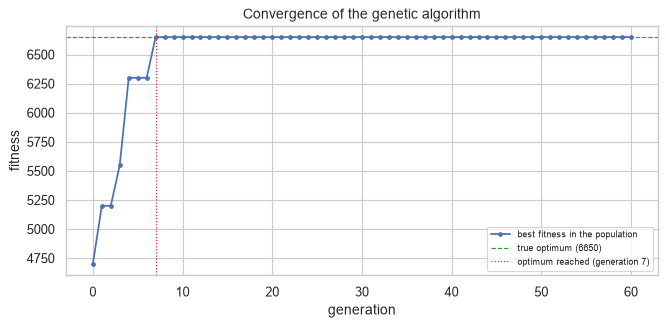

The optimum is reached at generation 7, after about 400 fitness evaluations (2.4% of the full search space).


In [7]:
history = np.array(ga_instance.best_solutions_fitness)
first_hit = int(np.flatnonzero(history >= OPTIMUM)[0])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history, marker="o", markersize=3, label="best fitness in the population")
ax.axhline(OPTIMUM, color="tab:green", linestyle="--", linewidth=1, label=f"true optimum ({OPTIMUM})")
ax.axvline(first_hit, color="tab:red", linestyle=":", linewidth=1, label=f"optimum reached (generation {first_hit})")
ax.set(title="Convergence of the genetic algorithm", xlabel="generation", ylabel="fitness")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"The optimum is reached at generation {first_hit}, "
      f"after about {(first_hit + 1) * POPULATION_SIZE:,} fitness evaluations "
      f"({100 * (first_hit + 1) * POPULATION_SIZE / len(combinations):.1f}% of the full search space).")

## Step 6: The Effect of Crossover and Mutation

A single run proves little — a genetic algorithm is stochastic, and one lucky seed says nothing. Every combination of four crossover types and four mutation types is therefore run with **20 different seeds**, and three things are recorded: how often the true optimum is found, how many generations it takes, and whether the returned solution is even feasible.

In [8]:
CROSSOVERS = ["single_point", "two_points", "uniform", "scattered"]
MUTATIONS = ["random", "swap", "inversion", "scramble"]
SEEDS = range(20)


def run_ga(crossover_type, mutation_type, seed, mutation_percent=10, population=50,
           parents=10, selection="sss", generations=60, fitness=fitness_func):
    """One GA run; returns the best solution found and when it first reached the optimum."""
    start = np.random.default_rng(1000 + seed).integers(0, 2, size=(population, N_ITEMS))

    ga = pygad.GA(num_generations=generations,
                  num_parents_mating=parents,
                  fitness_func=fitness,
                  initial_population=start,
                  gene_type=int,
                  gene_space=[0, 1],
                  parent_selection_type=selection,
                  keep_parents=2,
                  crossover_type=crossover_type,
                  mutation_type=mutation_type,
                  mutation_percent_genes=mutation_percent,
                  random_seed=seed,
                  suppress_warnings=True)
    ga.run()

    best, _, _ = ga.best_solution()
    best = np.array(best)
    reached = np.flatnonzero(np.array(ga.best_solutions_fitness) >= OPTIMUM)

    return {"value": int(best @ VALUES),
            "weight": int(best @ WEIGHTS),
            "feasible": int(best @ WEIGHTS) <= CAPACITY,
            "generation": int(reached[0]) if reached.size else None}


results = []
for crossover in CROSSOVERS:
    for mutation in MUTATIONS:
        runs = [run_ga(crossover, mutation, seed) for seed in SEEDS]
        found = [r["generation"] for r in runs if r["generation"] is not None]

        results.append({
            "crossover": crossover,
            "mutation": mutation,
            "optimum found, %": 100 * len(found) / len(runs),
            "mean generations": np.mean(found) if found else np.nan,
            "mean gap to optimum, %": 100 * np.mean([(OPTIMUM - r["value"]) / OPTIMUM for r in runs]),
            "feasible solutions, %": 100 * np.mean([r["feasible"] for r in runs]),
        })

experiment = pd.DataFrame(results)
experiment.round(2)

,crossover,mutation,"optimum found, %",mean generations,"mean gap to optimum, %","feasible solutions, %"
0,single_point,random,100.0,8.50,0.00,100.0
1,single_point,swap,15.0,3.00,4.55,70.0
2,single_point,inversion,90.0,9.56,0.64,95.0
3,single_point,scramble,95.0,6.84,0.75,100.0
4,two_points,random,100.0,6.50,0.00,100.0
5,two_points,swap,25.0,2.60,4.02,80.0
6,two_points,inversion,85.0,6.24,0.79,100.0
7,two_points,scramble,100.0,6.25,0.00,100.0
8,uniform,random,100.0,6.30,0.00,100.0
9,uniform,swap,30.0,3.17,4.29,75.0


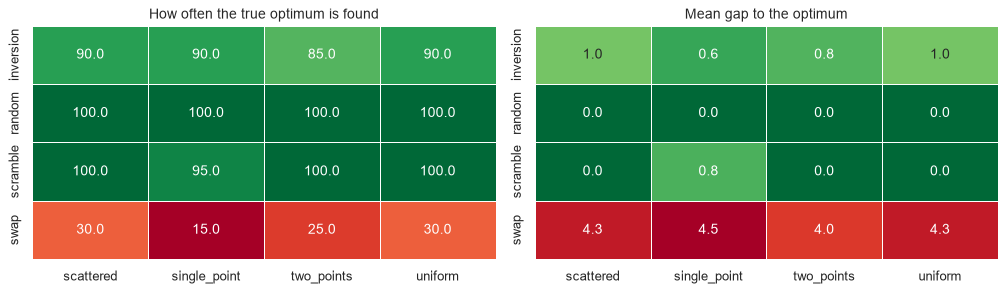

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for ax, metric, title in zip(axes,
                             ["optimum found, %", "mean gap to optimum, %"],
                             ["How often the true optimum is found", "Mean gap to the optimum"]):
    grid = experiment.pivot(index="mutation", columns="crossover", values=metric)
    sns.heatmap(grid, annot=True, fmt=".1f", cmap="RdYlGn" if "found" in metric else "RdYlGn_r",
                cbar=False, linewidths=0.5, ax=ax)
    ax.set(title=title, xlabel="", ylabel="")

plt.tight_layout()
plt.show()

The crossover type barely matters — all four reach the optimum in every run as long as the mutation is `random`. The **mutation type decides everything**: `swap` finds the optimum in 15–30% of runs, `inversion` and `scramble` in 85–100%, `random` always.

The reason is structural rather than a matter of tuning. `swap`, `inversion` and `scramble` are *permutation* operators — they rearrange genes, which is what ordering problems like the travelling salesman need. Rearranging a binary chromosome cannot change how many ones it contains, so these operators cannot alter how many items are packed.

In [10]:
sample = np.random.default_rng(7).integers(0, 2, size=(200, N_ITEMS))

preservation = []
for mutation in MUTATIONS:
    probe = pygad.GA(num_generations=1, num_parents_mating=10, fitness_func=fitness_func,
                     initial_population=sample.copy(), gene_type=int, gene_space=[0, 1],
                     mutation_type=mutation, mutation_percent_genes=30, crossover_type=None,
                     random_seed=RANDOM_STATE, suppress_warnings=True)
    mutated = np.array(probe.mutation(sample.copy()))

    preservation.append({
        "mutation": mutation,
        "chromosomes whose item count is unchanged, %":
            100 * np.mean(sample.sum(axis=1) == mutated.sum(axis=1)),
    })

print(f"A random chromosome packs {sample.sum(axis=1).mean():.1f} items on average; "
      f"the optimum packs {optimal_chromosome.sum()}.\n")
pd.DataFrame(preservation).round(1)

A random chromosome packs 7.0 items on average; the optimum packs 5.



,mutation,"chromosomes whose item count is unchanged, %"
0,random,48.0
1,swap,100.0
2,inversion,100.0
3,scramble,100.0


Confirmed: the three permutation operators leave the number of packed items untouched in **100%** of chromosomes, while `random` mutation changes it in about half of them. Since a random starting chromosome packs about 7 items and the optimum packs 5, a population under permutation-only mutation has to rely entirely on crossover to shed items — which is exactly why `swap`, the smallest of those rearrangements, performs worst.

### Feasibility Is Not Guaranteed

One column of the table deserves attention: with `swap` mutation some runs return an **overweight** solution. That is not a bug in the penalty — the best overweight packing scores 6400, which beats any feasible packing worth less than that, so a search that never finds anything good enough can legitimately end on an infeasible one. With a graded penalty the final answer must always be checked against the constraint, as it was in Step 5.

## Tuning the Remaining Parameters

With `two_points` crossover and `random` mutation fixed, the other knobs are swept one at a time over 30 seeds each. Efficiency is measured in **fitness evaluations** rather than generations, since a larger population buys faster convergence at a proportionally higher cost per generation.

In [11]:
def sweep(label, **kwargs):
    population = kwargs.get("population", 50)
    runs = [run_ga("two_points", "random", seed, **kwargs) for seed in range(30)]
    found = [r["generation"] for r in runs if r["generation"] is not None]

    return {"setting": label,
            "optimum found, %": 100 * len(found) / len(runs),
            "mean generations": round(np.mean(found), 1) if found else np.nan,
            "fitness evaluations": round(np.mean(found) * population) if found else np.nan}


sweeps = []
for percent in (5, 10, 20, 30, 50):
    sweeps.append(sweep(f"mutation_percent_genes = {percent}", mutation_percent=percent))
for population in (10, 20, 50, 100, 200):
    sweeps.append(sweep(f"sol_per_pop = {population}", population=population))
for parents in (2, 5, 10, 25, 40):
    sweeps.append(sweep(f"num_parents_mating = {parents}", parents=parents))

pd.DataFrame(sweeps)

,setting,"optimum found, %",mean generations,fitness evaluations
0,mutation_percent_genes = 5,100.000000,6.6,332
1,mutation_percent_genes = 10,100.000000,6.6,332
2,mutation_percent_genes = 20,100.000000,11.1,555
3,mutation_percent_genes = 30,40.000000,37.5,1875
4,mutation_percent_genes = 50,20.000000,25.0,1250
5,sol_per_pop = 10,46.666667,33.1,331
6,sol_per_pop = 20,100.000000,13.7,275
7,sol_per_pop = 50,100.000000,6.6,332
8,sol_per_pop = 100,100.000000,3.5,350
9,sol_per_pop = 200,100.000000,3.5,700


**Mutation rate** is the sharpest trade-off: 5–10% of genes converges in under 7 generations, 30% drops the success rate to 40% and 50% to 20% — at that point mutation destroys good solutions faster than selection can preserve them, and the search degenerates into a random walk.

**Population size** below 20 starves the search (47% success at 10 chromosomes), but beyond 20 the extra individuals mostly buy fewer generations at the same total cost — 20 chromosomes reach the optimum in about 275 evaluations against 350 for 100.

**Parent count** has a mild optimum around 5 of 50. Too few parents and diversity collapses; too many and weak chromosomes get to reproduce.

### Selection, and Why the Penalty Design Matters

The selection operator interacts with the fitness function in a way that is easy to miss. Fitness-proportional methods — roulette wheel (`rws`) and stochastic universal sampling (`sus`) — build probabilities from fitness values and implicitly assume those are non-negative. Here 76% of chromosomes have negative fitness. The sweep below runs each selection method twice: once with the penalty as defined, and once with the fitness clipped at zero.

In [12]:
def fitness_clipped(ga_instance, solution, solution_idx):
    """The same fitness, floored at zero so that it is never negative."""
    return max(0.0, float(fitness_func(ga_instance, solution, solution_idx)))


selection_results = []
for selection in ("sss", "tournament", "rws", "sus", "rank"):
    for label, fitness in (("penalty may go negative", fitness_func),
                           ("fitness clipped at 0", fitness_clipped)):
        runs = [run_ga("two_points", "random", seed, selection=selection, fitness=fitness)
                for seed in range(20)]
        found = [r["generation"] for r in runs if r["generation"] is not None]

        selection_results.append({
            "selection": selection,
            "fitness": label,
            "optimum found, %": 100 * len(found) / len(runs),
            "mean generations": round(np.mean(found), 1) if found else np.nan,
        })

pd.DataFrame(selection_results).pivot(index="selection", columns="fitness",
                                      values="optimum found, %")

fitness,fitness clipped at 0,penalty may go negative
selection,,
rank,0.0,0.0
rws,100.0,0.0
sss,100.0,100.0
sus,100.0,0.0
tournament,100.0,100.0


`rws` and `sus` go from never finding the optimum to always finding it, purely by flooring the fitness at zero — the fitness function and the selection operator cannot be designed independently. `sss` and `tournament` compare chromosomes rather than weigh them, so they are indifferent to the scale and work either way. `rank` failed in every configuration tried here, including with clipped fitness and with elitism varied, and its best fitness never improved on the initial population across 300 generations; it was left aside rather than diagnosed further.

## Step 7: Conclusion

**The genetic algorithm solves this instance reliably and cheaply.** With `random` mutation it reaches the exact brute-force optimum of 6650 in 100% of runs across every crossover type, in six to eight generations — a few hundred fitness evaluations against the 16384 chromosomes of the full space, some 2% of it. For reference, the greedy value-per-weight heuristic lands 4.5% below the optimum on this instance, so the search is doing real work.

**The best parameter set found:** `random` mutation at 5–10% of genes, any of the four crossover types (`two_points` and `scattered` converge marginally faster), `sss` or `tournament` selection, `sol_per_pop` of 20–50, `num_parents_mating` around 5, and elitism on so the best solution cannot be lost.

**Two choices matter far more than the rest.** The mutation operator is the first: permutation-style mutations cannot change how many items a chromosome packs, which on a binary encoding removes exactly the move the problem requires, and `swap` drops the success rate to 15–30%. The second is the pairing of the fitness function with the selection operator: a graded penalty gives the search a gradient back towards feasibility, but it produces negative values that silently break fitness-proportional selection until the fitness is floored at zero.

**And the caveat that comes with a soft penalty:** an overweight chromosome can outscore a mediocre feasible one, so a weak configuration can return an infeasible answer. The constraint has to be verified on the result, not assumed from the fitness design.